In [1]:
# %pip install langgraph langchain pymongo motor pydantic
# %pip install -U google-genai
# %pip install langchain-groq

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from typing import TypedDict, Dict, List, Any, Optional


class MedicalState(TypedDict):
    # ---------------- User ---------------- #
    user_id: str
    input_type: str        # text | image | pdf

    # ---------------- Input ---------------- #
    raw_input: Dict[str, Any]
    """
        "text": "...",
        "images": [...]
    """
    parsed_data: Dict[str, Any]
    query: str

    # ---------------- Memory ---------------- #
    retrieved_context: Dict[str, Any]
    """
        "patient_profile": {},
        "semantic_memories": [],
        "current_session": []
        "medical_knowledge": []
    """
    # ---------------- Reasoning ---------------- #
    medical_reasoning_output: str
    verification_result: Dict[str, Any]
    # safety_status: str
    final_answer: str
    output:str
    retry_count: int

In [4]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer(
    "BAAI/bge-small-en-v1.5"
)

E:\Hackathon\WellNest\WellNest\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 3142.45it/s]


In [5]:
from motor.motor_asyncio import AsyncIOMotorClient
import os

MONGO_URI = os.getenv("MONGO_URL")

client = AsyncIOMotorClient(MONGO_URI)
db = client["medical_ai"]

session_summaries = db["session_summaries"]
patient_profiles = db["patient_profiles"]

In [6]:
# {
#   "fields": [
#     {
#       "type": "vector",
#       "path": "embedding",
#       "numDimensions": 384,
#       "similarity": "cosine"
#     },
#     {
#       "type": "filter",
#       "path": "user_id"
#     }
#   ]
# }

In [7]:
async def retrieve_relevant_memories(
    user_id: str,
    query: str,
    k: int = 5,
):
    query_embedding = embedder.encode(
        query,
        normalize_embeddings=True
    ).tolist()

    pipeline = [
        {
            "$vectorSearch": {
                "index": "summary_vector_index",
                "path": "embedding",
                "queryVector": query_embedding,
                "numCandidates": 100,
                "limit": k,
                "filter": {
                    "user_id": user_id
                }
            }
        },
        {
            "$project": {
                "_id": 0,
                "summary": 1,
                "structured_data": 1,
                "score": {
                    "$meta": "vectorSearchScore"
                }
            }
        }
    ]

    semantic_memories = await session_summaries.aggregate(
        pipeline
    ).to_list(length=k)
    semantic_memories = [ m for m in semantic_memories if m["score"] > 0.7 ]
    
    patient_profile = await patient_profiles.find_one(
        {"user_id": user_id},
    )
    
    return {
        "semantic_memories": semantic_memories,
        "patient_profile": patient_profile or {}
    }

In [8]:
# from datetime import datetime

# async def append_message(
#     session_id: str,
#     user_id: str,
#     message: dict
# ):
#     await chats.update_one(
#         {
#             "session_id": session_id,
#             "user_id": user_id
#         },
#         {
#             "$push": {
#                 "messages": message
#             },
#             "$set": {
#                 "last_activity": datetime.utcnow(),
#                 "status": "active",
#                 "summary_generated": False
#             },
#             "$inc": {
#                 "total_messages": 1
#             },
#             "$setOnInsert": {
#                 "session_id": session_id,
#                 "user_id": user_id,
#                 "created_at": datetime.utcnow()
#             }
#         },
#         upsert=True
#     )

In [9]:
def has_images(state: MedicalState) -> str:
    """
    LangGraph conditional node.

    Returns:
        "vision" -> if one or more images are present.
        "text"   -> if this is a text-only query.
    """

    raw = state["raw_input"]
    images = raw.get("images", [])

    if images:
        return "vision"

    state["parsed_data"] = {}
    state["query"] = raw.get("text", "").strip()

    return "text"

In [10]:
# graph.add_conditional_edges(
#     "START",
#     has_images,
#     {
#         "vision": "multimodal_medical_parser",
#         "text": "context_builder",
#     },
# )

# graph.add_edge(
#     "multimodal_medical_parser",
#     "context_builder",
# )

In [11]:
from google import genai
import json
import os

GEMINI_API_KEY = os.getenv("GOOGLE_API_KEY")

client = genai.Client(api_key=GEMINI_API_KEY)


def multimodal_medical_parser(state: MedicalState) -> MedicalState:
    """
    Parses one or more medical images (optionally with user text)
    into structured medical information for downstream retrieval.
    """

    raw = state["raw_input"]

    text = raw.get("text", "").strip()
    images = raw["images"]

    prompt = """
        You are an expert medical document parser.
        
        Your ONLY responsibility is structured information extraction.
        
        The input may contain:
        - one image
        - multiple images
        - multiple pages of the same PDF
        - optional user text describing the document
        
        Treat all uploaded images as belonging to the same medical document unless it is obvious they are unrelated.
        
        Extract as much structured information as possible.
        
        Return ONLY valid JSON.
        
        {
          "document_type": "",
          "patient": {
              "name": "",
              "age": "",
              "sex": ""
          },
          "symptoms": [],
          "conditions": [],
          "medications": [
              {
                  "name": "",
                  "dosage": "",
                  "frequency": "",
                  "duration": ""
              }
          ],
          "tests": [],
          "observations": [],
          "doctor_instructions": [],
          "entities": [],
          "confidence": 0.0
        }
        
        Do not explain anything.
        Do not answer medical questions.
        Do not use markdown.
        Return JSON only.
    """

    contents = [prompt]

    if text:
        contents.append(text)

    contents.extend(images)

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=contents,
    )

    parsed = json.loads(response.text)

    state["parsed_data"] = parsed

    # Build a retrieval-friendly query
    query_parts = []

    if text:
        query_parts.append(text)

    query_parts.extend(parsed.get("conditions", []))
    query_parts.extend(parsed.get("symptoms", []))
    query_parts.extend(parsed.get("tests", []))
    query_parts.extend(parsed.get("observations", []))
    query_parts.extend(parsed.get("entities", []))

    state["query"] = "\n".join(
        str(item).strip()
        for item in query_parts
        if str(item).strip()
    )

    return state

E:\Hackathon\WellNest\WellNest\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


In [12]:
async def context_builder(state: MedicalState) -> MedicalState:
    if not state["query"]:
        state["query"] = state["raw_input"].get("text", "")
        
    context = await retrieve_relevant_memories(
        user_id=state["user_id"],
        query=state["query"],
    )

    context["parsed_data"] = state.get("parsed_data", {})

    context["raw_text"] = state["raw_input"].get("text", "")

    state["retrieved_context"] = context

    return state

In [13]:
from tavily import TavilyClient
import os

TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

tavily = TavilyClient(api_key=TAVILY_API_KEY)


def medical_web_search_tool(query: str):
    """
    Searches trusted medical websites for disease and symptom information.

    This tool is intended ONLY for retrieving factual medical
    information. It does not recommend treatments or medications.
    """

    trusted_domains = [
        "mayoclinic.org",
        "medlineplus.gov",
        "cdc.gov",
        "who.int",
        "nhs.uk",
        "msdmanuals.com",
        "clevelandclinic.org"
    ]

    search_query = (
        f"{query} "
        "disease symptoms causes diagnosis "
        "site:" + " OR site:".join(trusted_domains)
    )

    results = tavily.search(
        query=search_query,
        max_results=5,
        search_depth="advanced",
        include_answer=True,
        include_raw_content=True,
    )

    return {
        "query": query,
        "answer": results.get("answer"),
        "documents": results.get("results", [])
    }

In [14]:
ans =  medical_web_search_tool(query="I have conjunctivitis")

In [15]:
ans

{'query': 'I have conjunctivitis',
 'answer': 'Conjunctivitis causes eye redness, itching, and discharge; it can be viral, bacterial, or allergic; treatment depends on the cause.',
 'documents': [{'url': 'https://www.mayoclinic.org/diseases-conditions/pink-eye/symptoms-causes/syc-20376355',
   'title': 'Pink eye (conjunctivitis) - Symptoms and causes - Mayo Clinic',
   'content': "Diseases & Conditions\n\n# Pink eye (conjunctivitis)\n\nRequest an Appointment\n\n   Symptoms & causes\n   Diagnosis & treatment\n   Doctors & departments\n\nPrint\n\n## Overview\n\nImage 13: Pink eye (conjunctivitis) Possible signs of pink eye (conjunctivitis) Enlarge image\n\nClose\n\n### Possible signs of pink eye (conjunctivitis)\n\nImage 14: Pink eye (conjunctivitis)\n\n### Possible signs of pink eye (conjunctivitis)\n\nPink eye is the inflammation or infection of the transparent membrane that lines your eyelid and eyeball. Typical symptoms include redness and a gritty sensation in your eye, along with i

In [16]:
from langchain_core.tools import tool
import json

@tool
def medical_web_search(query: str) -> str:
    """
    Search trusted medical resources for up-to-date medical information.
    Use this only when existing context is insufficient.
    """

    results = medical_web_search_tool(query)

    return json.dumps(results)

In [17]:
import json
from langgraph.types import Command
from typing import Literal


def medical_tool_node(
    state: MedicalState,
) -> Command[Literal["medical_reasoning"]]:

    tool_call = state["tool_calls"][0]

    result = medical_web_search.invoke(tool_call["args"])

    state["retrieved_context"]["medical_knowledge"] = json.loads(result)

    return Command(
        goto="medical_reasoning",
        update=state,
    )

E:\Hackathon\WellNest\WellNest\.venv\Lib\site-packages\langgraph\checkpoint\base\__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [18]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.types import Command
from typing import Literal
import json

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
    google_api_key=GEMINI_API_KEY,
    temperature=0,
)

decision_llm = llm.bind_tools(
    [medical_web_search]
)

def retrieval_decision_node(
    state: MedicalState,
) -> Command[Literal["medical_tool", "medical_reasoning"]]:

    context = state["retrieved_context"]

    prompt = f"""
        You are a medical retrieval planner.
        
        Your ONLY job is to decide whether external medical knowledge
        is required.
        
        Use the following information.
        
        Current Query:
        {state["query"]}
        
        Parsed Information:
        {json.dumps(state.get("parsed_data", {}), indent=2)}
        
        Patient Profile:
        {json.dumps(context.get("patient_profile", {}), indent=2)}
        
        Relevant Past Sessions:
        {json.dumps(context.get("semantic_memories", []), indent=2)}
        
        Already Retrieved Medical Knowledge:
        {json.dumps(context.get("medical_knowledge", []), indent=2)}
        
        Rules:
        
        - If existing information is sufficient,
          do NOT search.
        
        - Search ONLY when trusted external
          medical information would improve the answer.
        
        Return your decision.
    """

    decision = decision_llm.invoke(prompt)

    # state["retrieval_decision"] = decision.model_dump()
    # state["retrieval_query"] = decision.search_query

    if decision.tool_calls:
        return Command(
        goto="medical_tool",
        update=state,
    )

    return Command(
        goto="medical_reasoning",
        update=state,
    )

In [19]:
from pydantic import BaseModel

class ReasoningOutput(BaseModel):
    reasoning: str
    response: str
    confidence: float
    needs_more_information: bool
    red_flags: list[str]
    follow_up_questions: list[str]

In [20]:
import json

from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
    google_api_key=GEMINI_API_KEY,
    temperature=0
)

reasoning_llm = llm.with_structured_output(ReasoningOutput)

def medical_reasoning_node(state: MedicalState) -> Command[Literal["safety_verifier"]]:

    parsed = state.get("parsed_data", {})

    context = state.get("retrieved_context", {})

    prompt = f"""
        You are an experienced AI Medical Assistant.
        
        Your responsibilities are:
        
        - Understand the patient's current concern.
        - Consider the patient's long-term medical history.
        - Consider relevant previous medical conversations.
        - Consider any retrieved medical knowledge.
        - Explain your reasoning clearly.
        - DO NOT prescribe medications.
        - DO NOT recommend drug dosages.
        - Try to suggest some remedies for users releif.
        - If symptoms suggest a potentially serious condition, recommend seeking immediate medical attention.
        - If uncertain, explicitly acknowledge uncertainty rather than guessing.

        Current User Query: {state["query"]}

        Parsed Medical Information: {json.dumps(parsed, indent=2)}

        Patient Profile: {json.dumps(context.get("patient_profile", {}), indent=2)}

        Relevant Past Medical Sessions: {json.dumps(context.get("semantic_memories", []), indent=2)}

        Retrieved Medical Knowledge: {json.dumps(context.get("medical_knowledge", []), indent=2)}

        Provide a detailed medical reasoning process followed by a patient-friendly explanation.

        Return ONLY valid response.
    """

    result = reasoning_llm.invoke(prompt)
    
    state["medical_reasoning_output"] = result.reasoning
    state["final_answer"] = result.response
    
    state["reasoning_metadata"] = {
        "confidence": result.confidence,
        "needs_more_information": result.needs_more_information,
        "red_flags": result.red_flags,
        "follow_up_questions": result.follow_up_questions,
    }

    return Command(
                goto="safety_verifier", 
                update=state,
            )

In [21]:
from typing import Optional
from pydantic import BaseModel, Field
from typing import Literal

class VerificationResult(BaseModel):
    status: Literal["ACCEPT", "RETRY", "REJECT"]
    medical_query: bool
    reason: str
    revised_query: Optional[str] = None

In [22]:
from langchain_google_genai import ChatGoogleGenerativeAI
import json
import os

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
    google_api_key=GEMINI_API_KEY,
    temperature=0
)

verifier_llm = llm.with_structured_output(VerificationResult)

def safety_verifier(state: MedicalState) -> MedicalState:
    """
    Independent verification node.

    This node does NOT generate medical advice.
    It evaluates the reasoning model's response and decides
    whether additional retrieval or another reasoning pass is needed.
    """

    context = state["retrieved_context"]

    prompt = f"""
                You are an independent medical AI verifier.
                
                You are NOT the medical assistant.
                
                Your ONLY job is to evaluate another AI's response.
                
                Evaluate the following:
                
                1. Is the user's request medically related?
                
                2. Is the response:
                    - medically reasonable
                    - internally consistent
                    - safe
                    - factually plausible
                    - complete
                
                3. Does the response require additional medical knowledge from trusted external medical sources?
                
                4. Should the reasoning pipeline retry after obtaining additional medical knowledge?
                
                5. If external knowledge is needed,produce an improved search query.
                
                Return ONLY valid response.
                
                User Query: {state["query"]}
                
                Parsed Medical Information: {json.dumps(context.get("parsed_data", {}), indent=2)}
                
                Patient Profile: {json.dumps(context.get("patient_profile", {}), indent=2)}
                
                Relevant Medical Memories: {json.dumps(context.get("semantic_memories", []), indent=2)}
                
                External Medical Knowledge: {json.dumps(context.get("medical_knowledge", []), indent=2)}
                
                AI Reasoning: {state["medical_reasoning_output"]}
                
                AI Response: {state["final_answer"]}
            """

    response = verifier_llm.invoke(prompt)

    # result = json.loads(
    #     response.choices[0].message.content
    # )

    state["verification_result"] = response.model_dump()

    return state

In [23]:
MAX_RETRIES = 2

def verification_router(state: MedicalState):

    result = state["verification_result"]

    if not result["medical_query"]:
        return "reject"

    if result["status"] == "RETRY" and state["retry_count"] < MAX_RETRIES :
        state["retry_count"] += 1
        
        if  result["revised_query"] != "":
            state["query"] = result["revised_query"]
            
        state["verification_result"] = {}
        
        return "retry"

    if result["status"] == "ACCEPT":
        state["retry_count"] = 0
        
    return "accept"

In [24]:
from langgraph.graph import END
from langgraph.types import Command
from typing import Literal


def final_node(state: MedicalState) -> Command[Literal[END]]:
    """
    Final node of the graph.

    Responsibilities:
    - Prepare the final API response.
    - Remove internal fields if desired.
    - Trigger any future logging/background tasks.
    """

    state["output"] = {
        "answer": state["final_answer"],
        "reasoning": state["medical_reasoning_output"],
        "verification": state.get("verification_result", {}),
        "metadata": state.get("reasoning_metadata", {}),
    }

    return Command(
        goto=END,
        update=state,
    )

In [25]:
from langgraph.graph import StateGraph,START, END
graph = StateGraph(MedicalState)

In [26]:
graph.add_node("multimodal_medical_parser", multimodal_medical_parser)
graph.add_node("context_builder", context_builder)
graph.add_node("retrieval_decision", retrieval_decision_node)
graph.add_node("medical_tool", medical_tool_node)
graph.add_node("medical_reasoning", medical_reasoning_node)
graph.add_node("safety_verifier", safety_verifier)
graph.add_node("final", final_node)

In [27]:
# graph.add_edge("context_builder", "medical_reasoning")
graph.add_edge(
    "context_builder",
    "retrieval_decision",
)
graph.add_edge("medical_reasoning", "safety_verifier")
graph.add_edge(
    "multimodal_medical_parser",
    "context_builder",
)
graph.add_edge("medical_tool", "medical_reasoning")


In [28]:
graph.add_conditional_edges(
    START,
    has_images,
    {
        "vision": "multimodal_medical_parser",
        "text": "context_builder",
    },
)

In [29]:
graph.add_conditional_edges(
    "safety_verifier",
    verification_router,
    {
        "reject" : "final",
        "retry": "context_builder",
        "accept": "final"
    }
)

In [30]:
app = graph.compile()

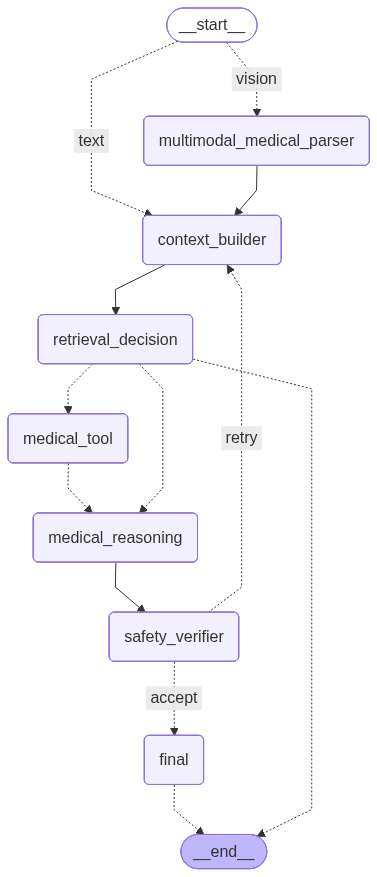

In [31]:
from IPython.display import Image, display

# Get graph visualization
graph_image = app.get_graph().draw_mermaid_png()

display(Image(graph_image))

In [32]:
import asyncio

initial_state: MedicalState = {
    "user_id": "user_123",
    "input_type": "text",
    "raw_input": {
        "text": "I took paracetamol 650mg for fever",
        "images": []
    },
    "parsed_data": {},
    "query": "",
    "retrieved_context": {},
    "medical_reasoning_output": "",
    "verification_result": {},
    "final_answer": "",
    "output": "",
    "retry_count": 0,
}

# async for event in app.astream(initial_state):
#     print("=" * 80)
#     for node, state in event.items():
#         print(f"NODE: {node}")
#         print(state)

# result = await app.invoke(initial_state)

In [33]:
result = await app.ainvoke(initial_state)

print(result["output"])

{'answer': "Paracetamol 650mg is a common dosage for fever. While I cannot provide medical advice or recommendations, general measures for fever relief include resting, staying hydrated by drinking plenty of fluids like water, clear broths, or electrolyte solutions, and using a lukewarm compress on your forehead. If your fever persists, worsens, or is accompanied by other concerning symptoms such as a severe headache, stiff neck, difficulty breathing, or a rash, please seek immediate medical attention from a healthcare professional. It's always best to consult with your doctor for any health concerns.", 'reasoning': "The user has stated that they took paracetamol 650mg for fever. This is a standard dose for an adult. My primary responsibility is to act as a medical assistant, not to prescribe or recommend dosages. Therefore, I should acknowledge the user's statement and provide general advice regarding fever management without giving specific medical instructions. I need to ensure I do

In [34]:
result = result["output"]

print("=" * 80)
print("🩺 MEDICAL AI RESPONSE")
print("=" * 80)

print("\n📋 Answer")
print("-" * 80)
print(result["answer"])

print("\n🧠 Reasoning")
print("-" * 80)
print(result["reasoning"])

verification = result["verification"]

print("\n✅ Verification")
print("-" * 80)
print(f"Status          : {verification['status']}")
print(f"Medical Query   : {verification['medical_query']}")
print(f"Reason          : {verification['reason']}")

if verification.get("revised_query"):
    print(f"Revised Query   : {verification['revised_query']}")

metadata = result.get("metadata", {})

if metadata:
    print("\n📊 Metadata")
    print("-" * 80)
    for key, value in metadata.items():
        print(f"{key}: {value}")

print("=" * 80)

🩺 MEDICAL AI RESPONSE

📋 Answer
--------------------------------------------------------------------------------
Paracetamol 650mg is a common dosage for fever. While I cannot provide medical advice or recommendations, general measures for fever relief include resting, staying hydrated by drinking plenty of fluids like water, clear broths, or electrolyte solutions, and using a lukewarm compress on your forehead. If your fever persists, worsens, or is accompanied by other concerning symptoms such as a severe headache, stiff neck, difficulty breathing, or a rash, please seek immediate medical attention from a healthcare professional. It's always best to consult with your doctor for any health concerns.

🧠 Reasoning
--------------------------------------------------------------------------------
The user has stated that they took paracetamol 650mg for fever. This is a standard dose for an adult. My primary responsibility is to act as a medical assistant, not to prescribe or recommend dosa